# 04 - Stable Diffusion 1.5 with Line-Art ControlNet

The second approach begins with a pretrained image distribution rather than learning facial appearance entirely from the paired dataset. Stable Diffusion 1.5 supplies a latent-space denoiser and a variational autoencoder; Line-Art ControlNet supplies spatial conditioning from the sketch. The experiment adapts the published ControlNet weights while freezing the SD U-Net, VAE and text encoder.

Two weight states are evaluated: **SD 1.5 + published Line-Art ControlNet**, and **SD 1.5 + Line-Art ControlNet fine-tuned on face pairs**. Both are pretrained systems. The difference is the additional face-pair training of ControlNet, not whether pretraining was used.

The starting checkpoints are [SD 1.5](https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5) and [Line-Art ControlNet](https://huggingface.co/lllyasviel/control_v11p_sd15_lineart), with pinned revisions in the loading cell. The training path follows the [Diffusers ControlNet implementation](https://huggingface.co/docs/diffusers/v0.35.1/en/training/controlnet).

Embedded training results: September 30, 2026, L40S; 1,000 ControlNet updates. Figures are rendered from that completed run.

## Selected adaptation examples

Validation pairs **7 and 15** were selected visually from the 16-pair panel to illustrate favorable outcomes of adaptation. Each comparison uses the same SD 1.5 backbone, prompt and sampling seed before and after 1,000 ControlNet updates. The complete panel is retained in notebook 05.

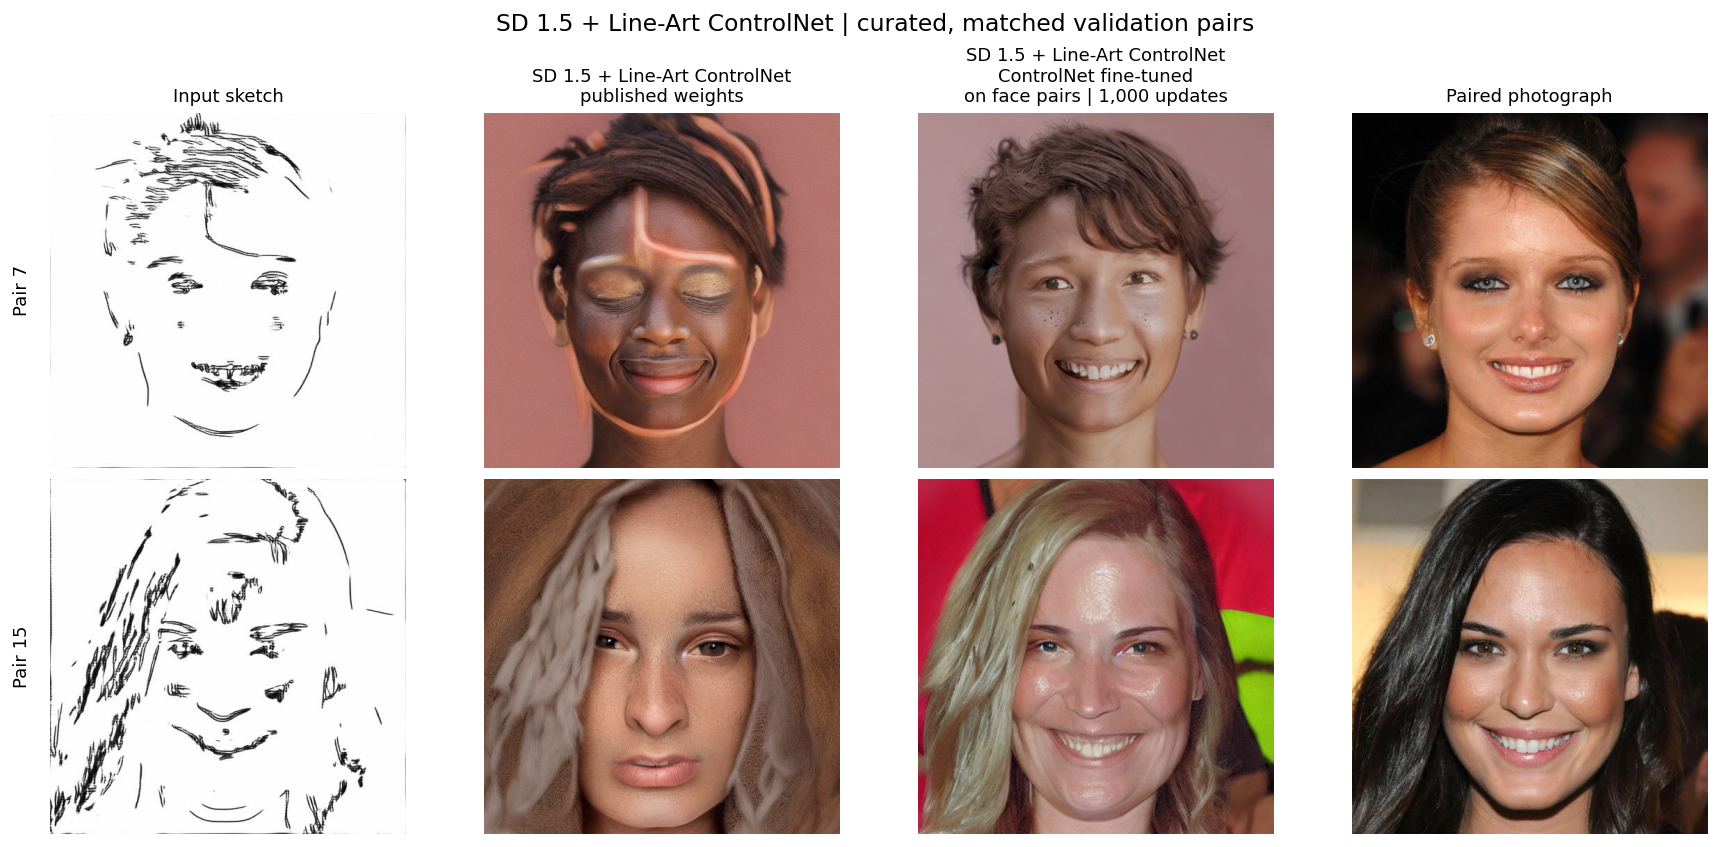

In [1]:
from pathlib import Path
from time import perf_counter
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from diffusers import DDPMScheduler
from tqdm.auto import tqdm

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
from models.pretrained_controlnet import (
    load_controlnet_pipeline, encode_prompts, control_image, latent_diffusion_loss,
)
from utils.data import make_dataloader, denormalize

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


## Image and conditioning representations

The paired images are resized to $512\times512$ and use the same geometric augmentation as UNetV2. Photographs enter the VAE in RGB $[-1,1]$. Sketches retain their pencil shading and dark-on-white polarity; their grayscale channel is repeated to form the RGB $[0,1]$ input expected by ControlNet.

A single portrait prompt supplies the text condition $c$ for every pair. It specifies photographic appearance without pair-specific descriptions of identity or expression, leaving the sketch as the varying spatial condition. Evaluation uses 16 fixed, unaugmented validation pairs.

In [2]:
manifest_path = ROOT / 'data/processed/pairs.csv'
train_loader = make_dataloader(
    manifest_path, split='train', image_size=512, batch_size=1,
    repeat=1, num_workers=2, random_transform=True, affine=True,
)
val_loader = make_dataloader(
    manifest_path, split='val', image_size=512, batch_size=1, max_items=16,
    shuffle=False, num_workers=2, random_transform=False,
)
validation_pairs = list(val_loader)
sketches = torch.cat([s for s, _ in validation_pairs])
photos = torch.cat([p for _, p in validation_pairs])
pair_keys = [
    (r['dataset'], Path(r['sketch_path']).name, Path(r['photo_path']).name)
    for r in val_loader.dataset.rows
]
print(f'Train: {train_loader.dataset.num_pairs:,} pairs; validation panel: {len(sketches)} pairs')


Train: 21,913 pairs; validation panel: 16 pairs


In [3]:
pipe = load_controlnet_pipeline(
    'stable-diffusion-v1-5/stable-diffusion-v1-5',
    'lllyasviel/control_v11p_sd15_lineart',
    device,
    base_revision='451f4fe16113bff5a5d2269ed5ad43b0592e9a14',
    controlnet_revision='8a158f547e031c5b8fbca19ead09a74767ff4db0',
)
noise_scheduler = DDPMScheduler.from_config(pipe.scheduler.config)
prompt = 'a realistic color portrait photograph of a person, natural skin texture'
prompt_embeds = encode_prompts(pipe, [prompt])
empty_embeds = encode_prompts(pipe, [''])
pipe.set_progress_bar_config(disable=True)
pipe.controlnet.eval()

parameter_counts = pd.DataFrame([
    dict(component=name, total_M=sum(p.numel() for p in module.parameters()) / 1e6,
         trainable_M=sum(p.numel() for p in module.parameters() if p.requires_grad) / 1e6)
    for name, module in [('VAE', pipe.vae), ('text encoder', pipe.text_encoder),
                         ('U-Net', pipe.unet), ('ControlNet', pipe.controlnet)]
])
display(parameter_counts)

,component,total_M,trainable_M
0,VAE,83.653863,0.00000
1,text encoder,123.060480,0.00000
2,U-Net,859.520964,0.00000
3,ControlNet,361.279120,361.27912


In [4]:
print(f'Pretrained target: {noise_scheduler.config.prediction_type}')

Pretrained target: epsilon


## Generation with published ControlNet weights

Before adaptation, the published model is evaluated with 30-step DDIM, ControlNet strength 1.0 and text-guidance scale $w=7.5$. For a fixed sketch $s$, classifier-free text guidance combines the empty-prompt and portrait-prompt predictions:

$$\hat\epsilon=\epsilon_\theta(z_t,s,\varnothing,t)
+w\left[\epsilon_\theta(z_t,s,c,t)-\epsilon_\theta(z_t,s,\varnothing,t)\right].$$

Both branches remain sketch-conditioned. The guidance scale therefore modifies the text-conditioning contribution; it does not measure sketch strength. Pair $i$ uses seed $123+i$, and these seeds and sampler settings are reused after adaptation.

A separate denoising diagnostic fixes the VAE posterior draws, diffusion noise and timesteps on the same 16 pairs. This provides a matched before/after comparison in latent space alongside the generated portraits.

In [5]:
@torch.no_grad()
def validation_loss():
    rng = torch.Generator(device=device).manual_seed(456)
    losses = []
    for s, p in validation_pairs:
        with torch.autocast(device_type=device.type, enabled=device.type == 'cuda'):
            loss = latent_diffusion_loss(
                pipe, noise_scheduler, s.to(device), p.to(device), prompt_embeds,
                generator=rng,
            )
        losses.append(loss.item())
    return sum(losses) / len(losses)


@torch.no_grad()
def sample_panel(panel, *, trace=False):
    images, frames, flags = [], [], []

    def keep_latent(pipeline, step, timestep, callback_kwargs):
        if step in (0, 5, 11, 19, 29):
            frames.append((step + 1, int(timestep), callback_kwargs['latents'].detach().cpu()))
        return callback_kwargs

    for i, sketch in enumerate(panel):
        with torch.autocast(device_type=device.type, enabled=device.type == 'cuda'):
            result = pipe(
                prompt_embeds=prompt_embeds, negative_prompt_embeds=empty_embeds,
                image=control_image(sketch[None].to(device)),
                num_inference_steps=30, guidance_scale=7.5,
                controlnet_conditioning_scale=1.0, eta=0.0,
                generator=torch.Generator(device=device).manual_seed(123 + i),
                output_type='pt',
                callback_on_step_end=keep_latent if trace and i == 0 else None,
                callback_on_step_end_tensor_inputs=['latents'],
            )
        images.append(result.images.cpu())
        flags.extend(result.nsfw_content_detected)
    return torch.cat(images), frames, flags


output_dir = ROOT / 'outputs/pretrained_lineart'
output_dir.mkdir(parents=True, exist_ok=True)
before_loss = validation_loss()
before, before_frames, before_flags = sample_panel(sketches, trace=True)
experiment = dict(
    pair_keys=pair_keys, sketches=sketches, photos=photos, before=before,
    before_frames=before_frames, before_flags=before_flags, before_loss=before_loss,
    prompt=prompt, base_model='stable-diffusion-v1-5/stable-diffusion-v1-5',
    base_revision='451f4fe16113bff5a5d2269ed5ad43b0592e9a14',
    controlnet_model='lllyasviel/control_v11p_sd15_lineart',
    controlnet_revision='8a158f547e031c5b8fbca19ead09a74767ff4db0',
    sampling=dict(steps=30, guidance_scale=7.5, control_strength=1.0,
                  seed_start=123, image_size=512, scheduler='DDIM', eta=0.0),
)
torch.save(experiment, output_dir / 'before.pt')
print(f'Before tuning: fixed-noise latent MSE = {before_loss:.4f}')


Before tuning: fixed-noise latent MSE = 0.1190


Safety-filtered outputs: 1 / 16


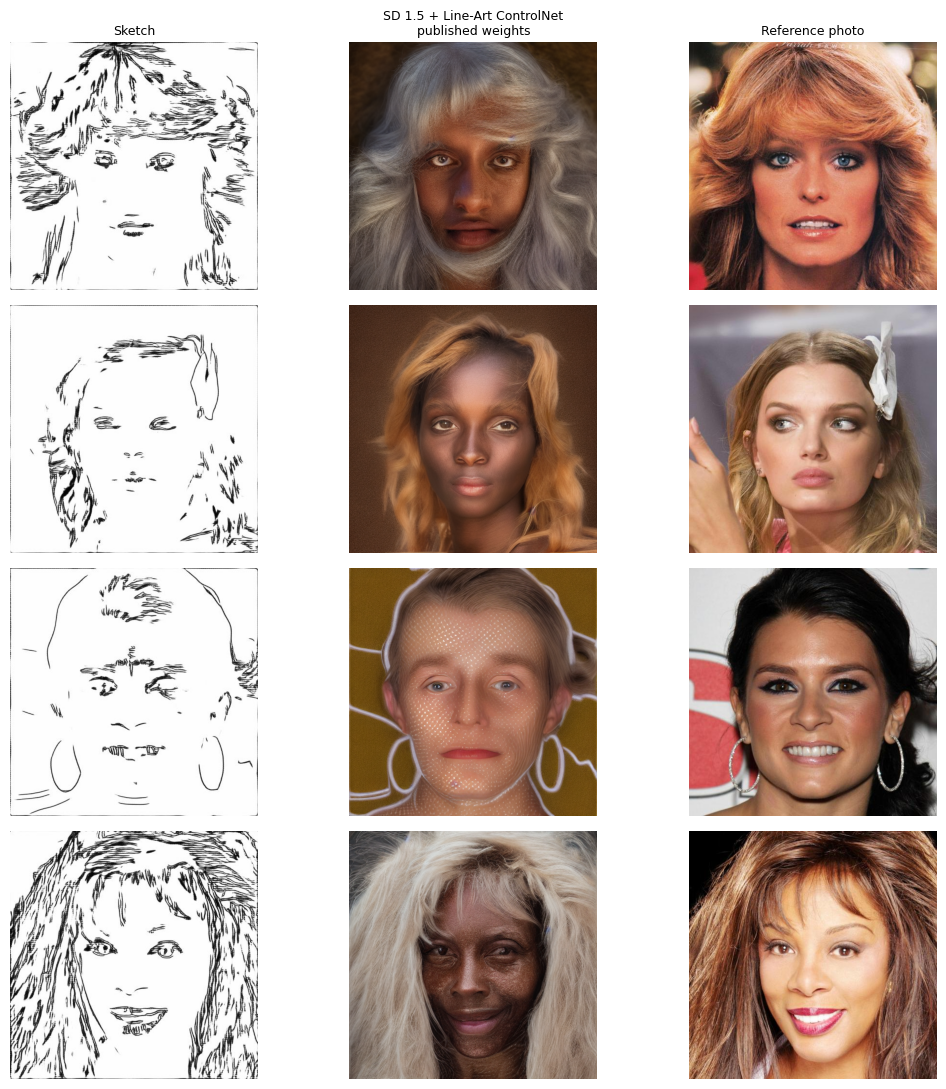

In [6]:
fig, axes = plt.subplots(4, 3, figsize=(11, 11), squeeze=False)
for i, row in enumerate(axes):
    for ax, image, title in zip(row, [control_image(sketches[i:i+1])[0], before[i], denormalize(photos[i])],
                                ['Sketch', 'SD 1.5 + Line-Art ControlNet\npublished weights', 'Reference photo']):
        ax.imshow(image.float().permute(1, 2, 0))
        ax.set_title(title if i == 0 else '', fontsize=9)
        ax.axis('off')
plt.tight_layout()
plt.savefig(output_dir / 'before.png', dpi=120, bbox_inches='tight')
print(f'Safety-filtered outputs: {sum(before_flags)} / {len(before_flags)}', flush=True)


## Latent diffusion and ControlNet adaptation

Unlike the pixel-space U-Nets, SD 1.5 denoises a compressed representation of the photograph. Its frozen VAE encoder defines a diagonal Gaussian posterior,

$$q_\phi(z\mid x)=\mathcal N\!\left(\mu_\phi(x),\operatorname{diag}(\sigma_\phi^2(x))\right),
\qquad z=\mu_\phi(x)+\sigma_\phi(x)\odot\epsilon_{\mathrm{enc}}.$$

Here $\epsilon_{\mathrm{enc}}\sim\mathcal N(0,I)$ samples the encoding distribution. The scaled latent $z_0=kz$, with the VAE's fixed scaling factor $k$, has shape $4\times64\times64$ for a $512\times512$ photograph. A second, independent Gaussian draw supplies the diffusion corruption:

$$z_t=\sqrt{\bar\alpha_t}\,z_0+\sqrt{1-\bar\alpha_t}\,\epsilon,
\qquad \epsilon\sim\mathcal N(0,I).$$

The schedule and noise-prediction target are inherited from SD 1.5. ControlNet processes the noisy latent, sketch and text condition, supplying residual features to the frozen U-Net. Let $\epsilon_\theta(z_t,s,c,t)$ denote the resulting joint prediction, with $\theta$ restricted to the trainable ControlNet parameters. The objective is

$$\mathcal L(\theta)=\mathbb E_{(s,x),z,t,\epsilon}
\left[\operatorname{MSE}\!\left(\epsilon_\theta(z_t,s,c,t),\epsilon\right)\right].$$

The posterior $q_\phi$ is not fitted in this experiment, and no VAE reconstruction or KL term is optimized. Gradients must nevertheless pass through the frozen U-Net to reach the ControlNet residuals. Freezing parameters does not make this gradient path unnecessary.

Adaptation consists of 1,000 optimizer updates at learning rate $10^{-5}$, each accumulating eight single-image batches: 8,000 paired presentations. The text condition is replaced by the empty prompt in 10% of training examples, while the sketch is retained. Validation is repeated every 250 updates.

In [7]:
pipe.controlnet.enable_gradient_checkpointing()
pipe.unet.enable_gradient_checkpointing()
optimizer = torch.optim.AdamW(pipe.controlnet.parameters(), lr=1e-5, weight_decay=0.01, foreach=False)
scaler = torch.amp.GradScaler('cuda', enabled=device.type == 'cuda')
tuned_dir = ROOT / 'checkpoints/pretrained_lineart/controlnet'
train_history = []
validation_history = [dict(update=0, val_loss=before_loss)]
train_iter = iter(train_loader)
started = perf_counter()

for update in tqdm(range(1, 1001), desc='ControlNet updates'):
    pipe.controlnet.train()
    optimizer.zero_grad(set_to_none=True)
    update_loss = 0.0
    for _ in range(8):
        s, p = next(train_iter)
        embeddings = empty_embeds if torch.rand(()) < 0.1 else prompt_embeds
        with torch.autocast(device_type=device.type, enabled=device.type == 'cuda'):
            loss = latent_diffusion_loss(
                pipe, noise_scheduler, s.to(device), p.to(device), embeddings,
            )
        scaler.scale(loss / 8).backward()
        update_loss += loss.item() / 8
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(pipe.controlnet.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()
    train_history.append(update_loss)
    if update % 25 == 0:
        print(f'update {update}/1000 | loss {sum(train_history[-25:]) / 25:.5f} | elapsed {perf_counter() - started:.0f}s', flush=True)

    if update % 250 == 0:
        pipe.controlnet.eval()
        val_loss = validation_loss()
        validation_history.append(dict(update=update, val_loss=val_loss))
        pd.DataFrame(validation_history).to_csv(output_dir / 'validation.csv', index=False)
        pd.DataFrame({'latent_MSE': train_history}).to_csv(output_dir / 'training.csv', index_label='update_index')
        preview, _, preview_flags = sample_panel(sketches[:4])
        fig, axes = plt.subplots(1, 4, figsize=(12, 3))
        for ax, image in zip(axes, preview):
            ax.imshow(image.float().permute(1, 2, 0)); ax.axis('off')
        fig.suptitle(f'SD 1.5 + Line-Art ControlNet | ControlNet tuning update {update} | filtered: {sum(preview_flags)}')
        fig.tight_layout()
        fig.savefig(output_dir / f'update_{update:04d}.png', dpi=120)
        plt.close(fig)
        print(f'update {update} | validation latent MSE {val_loss:.4f}', flush=True)

training_seconds = perf_counter() - started
pipe.controlnet.eval()
pipe.controlnet.save_pretrained(tuned_dir, safe_serialization=True)
print(f'{len(train_history)} updates, including validation: {training_seconds / 3600:.2f} hours')


update 25/1000 | loss 0.16263 | elapsed 29s


update 50/1000 | loss 0.13856 | elapsed 58s


update 75/1000 | loss 0.12806 | elapsed 88s


update 100/1000 | loss 0.15366 | elapsed 118s


update 125/1000 | loss 0.12713 | elapsed 148s


...

update 950/1000 | loss 0.13165 | elapsed 1169s


update 975/1000 | loss 0.14663 | elapsed 1199s


update 1000/1000 | loss 0.14764 | elapsed 1229s


update 1000 | validation latent MSE 0.1138


1000 updates, including validation: 0.35 hours


## Generation after face-pair adaptation

Only the ControlNet weights differ from the published-weight evaluation. Matched sketches, prompts and initial noise permit direct comparison of the resulting facial structure, expression, color and texture. The experiment measures the effect of a short adaptation run, not a converged estimate of the architecture's performance.

The latent-MSE curve measures the training task, whereas the image panels expose errors accumulated during iterative generation. These quantities can improve differently: a more accurate average noise estimate does not guarantee a better portrait for every condition.

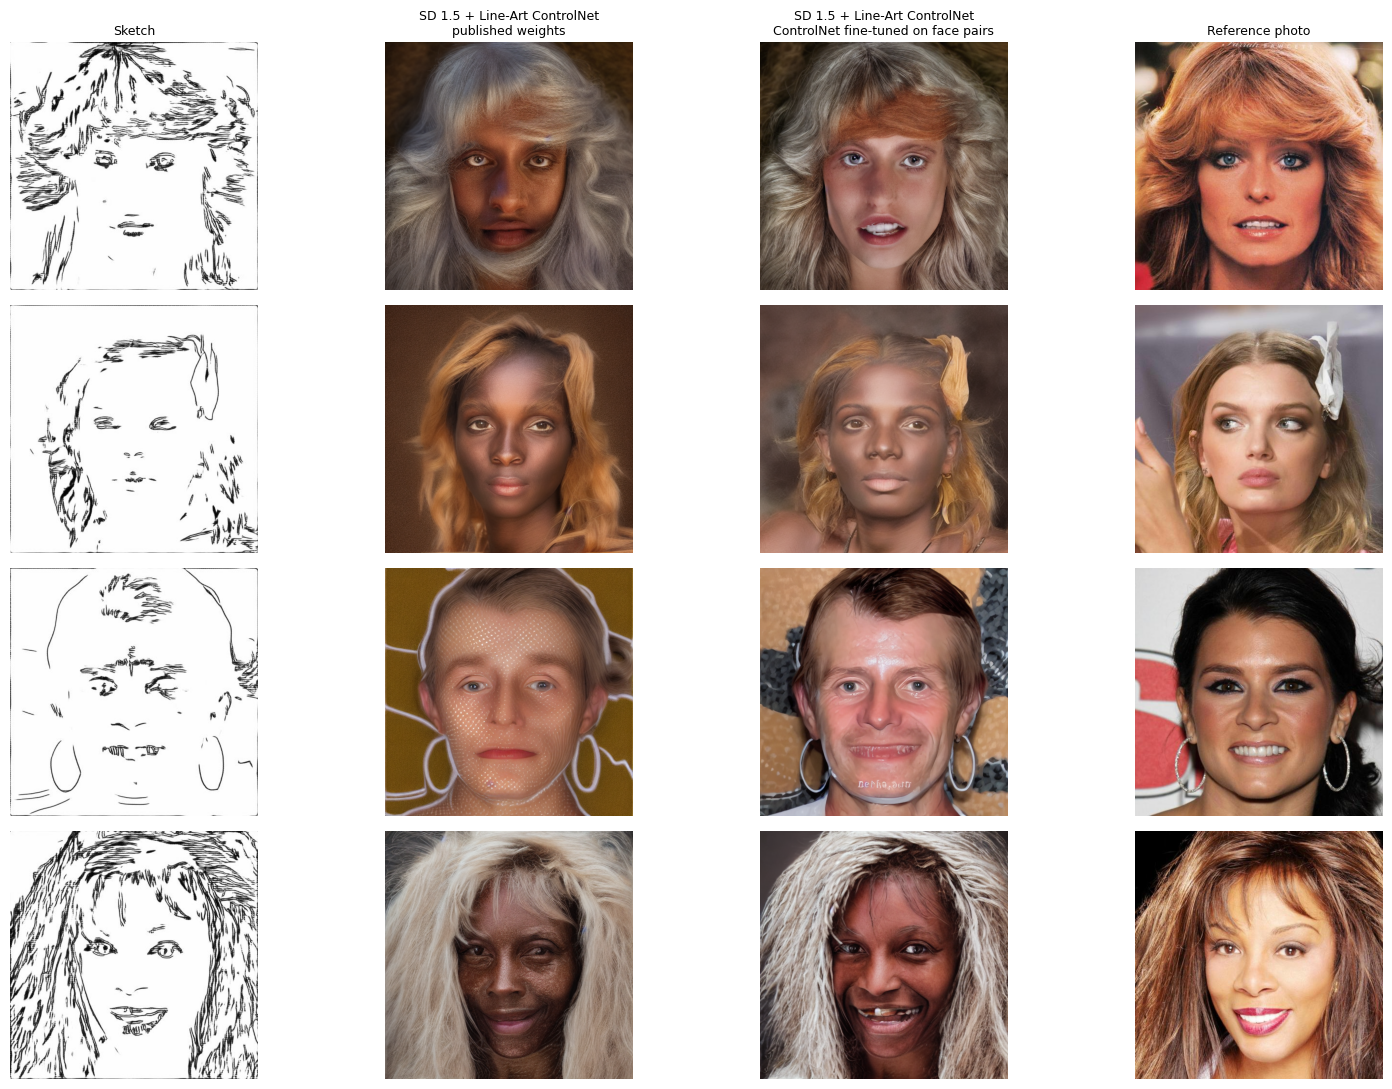

In [8]:
after_loss = validation_loss()
after, after_frames, after_flags = sample_panel(sketches, trace=True)
experiment.update(
    after=after, after_frames=after_frames, after_flags=after_flags,
    after_loss=after_loss, train_history=train_history,
    validation_history=validation_history, training_seconds=training_seconds,
    updates=len(train_history), examples_seen=len(train_history) * 8,
    parameter_counts=parameter_counts.to_dict('records'),
)
torch.save(experiment, output_dir / 'comparison.pt')

fig, axes = plt.subplots(4, 4, figsize=(16, 11), squeeze=False)
for i, row in enumerate(axes):
    for ax, image, title in zip(
        row, [control_image(sketches[i:i+1])[0], before[i], after[i], denormalize(photos[i])],
        ['Sketch', 'SD 1.5 + Line-Art ControlNet\npublished weights', 'SD 1.5 + Line-Art ControlNet\nControlNet fine-tuned on face pairs', 'Reference photo'],
    ):
        ax.imshow(image.float().permute(1, 2, 0))
        ax.set_title(title if i == 0 else '', fontsize=9)
        ax.axis('off')
plt.tight_layout()
plt.savefig(output_dir / 'before_after.png', dpi=140, bbox_inches='tight')
plt.show()

In [9]:
print("SD 1.5 + Line-Art ControlNet: published weights")
print(f"  Latent MSE: {before_loss:.4f}; filtered outputs: {sum(before_flags)}/{len(before_flags)}")
print("\nSD 1.5 + Line-Art ControlNet: ControlNet fine-tuned on face pairs")
print(f"  Latent MSE: {after_loss:.4f}; filtered outputs: {sum(after_flags)}/{len(after_flags)}")

SD 1.5 + Line-Art ControlNet: published weights
  Latent MSE: 0.1190; filtered outputs: 1/16

SD 1.5 + Line-Art ControlNet: ControlNet fine-tuned on face pairs
  Latent MSE: 0.1138; filtered outputs: 0/16


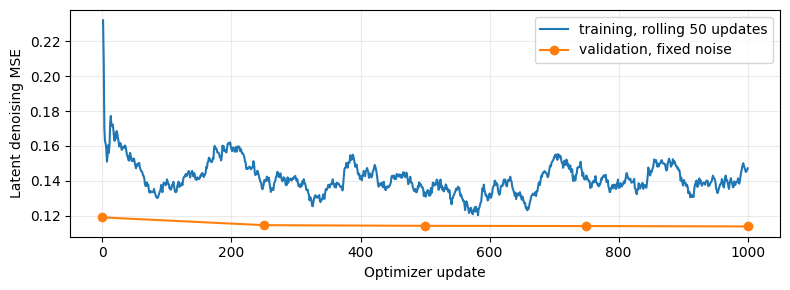

In [10]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(pd.Series(train_history, index=range(1, len(train_history) + 1)).rolling(50, min_periods=1).mean(),
        label='training, rolling 50 updates')
v = pd.DataFrame(validation_history)
ax.plot(v['update'], v['val_loss'], 'o-', label='validation, fixed noise')
ax.set(xlabel='Optimizer update', ylabel='Latent denoising MSE')
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout()


## Decoding the latent trajectory

Generation begins with $z_T\sim\mathcal N(0,I)$ and progressively denoises it under the sketch and text conditions. The VAE decoder maps each retained state back to image space:

$$\tilde x_t=D_\psi(z_t/k).$$

These are decoded noisy latents, rather than the denoiser's estimates of the final clean image. The frames compare how the two ControlNet weight states guide a shared initial sample toward different portraits. Since $D_\psi$ is frozen, differences between the rows arise from the latent trajectories rather than a changed image decoder.

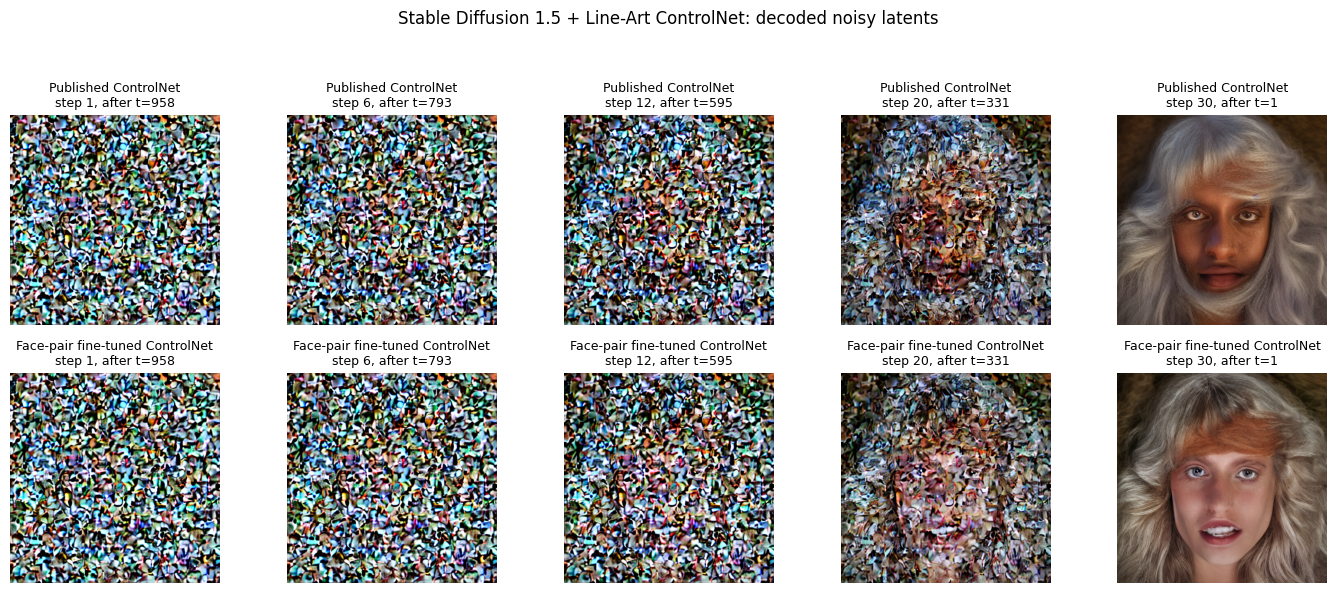

In [11]:
@torch.no_grad()
def decode_frames(frames):
    images = []
    for step, timestep, latent in frames:
        # D_psi(z_t / k): a decoded image, not a draw from q_phi(z | x).
        # DecoderOutput.sample is the image tensor; it does not sample a distribution.
        decoded = pipe.vae.decode(
            latent.to(device=device, dtype=pipe.vae.dtype) / pipe.vae.config.scaling_factor,
        ).sample
        images.append((step, timestep, denormalize(decoded[0].float().cpu())))
    return images

decoded_before = decode_frames(before_frames)
decoded_after = decode_frames(after_frames)
fig, axes = plt.subplots(2, len(decoded_before), figsize=(14, 6), squeeze=False)
for row, frames, label in zip(axes, [decoded_before, decoded_after], ['Published ControlNet', 'Face-pair fine-tuned ControlNet']):
    for ax, (step, t, image) in zip(row, frames):
        ax.imshow(image.float().permute(1, 2, 0))
        ax.set_title(f'{label}\nstep {step}, after t={t}', fontsize=9)
        ax.axis('off')
plt.tight_layout()
fig.suptitle('Stable Diffusion 1.5 + Line-Art ControlNet: decoded noisy latents', fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.savefig(output_dir / 'latent_trajectory.png', dpi=140, bbox_inches='tight')
